# Telco Customer Churn data analysis
#### Dataset from Kaggle.com, project by Jonas ATTLAN

## Context
Customer churn refers to the rate at which customers stop doing business with a company. Our primary goal is to identify the key variables driving this rate. Understanding these factors will allow us to design effective strategies to retain customers and maximize their lifetime value.

## Understanding the data

The first step of this project consists of importing the raw Kaggle dataset and exploring its initial structure. We will filter out irrelevant variables to focus on the core features. Finally, we will perform essential data cleaning, including handling missing values and ensuring all columns have the correct data types.

### Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/telco-customer-churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

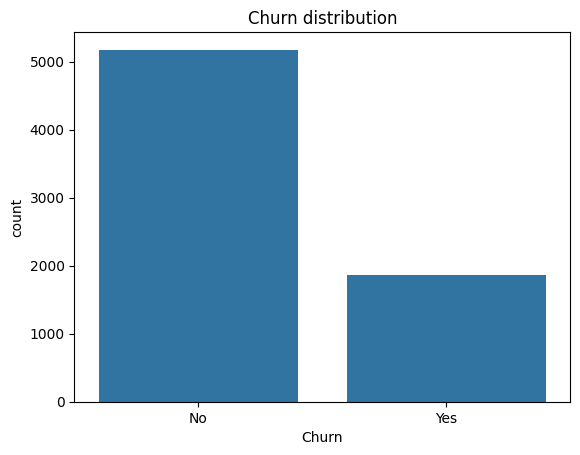

In [10]:
sns.countplot(x = "Churn", data = df)
plt.title("Churn distribution")
plt.show()

The dataset is imbalance, a majority of customers are non-churning.

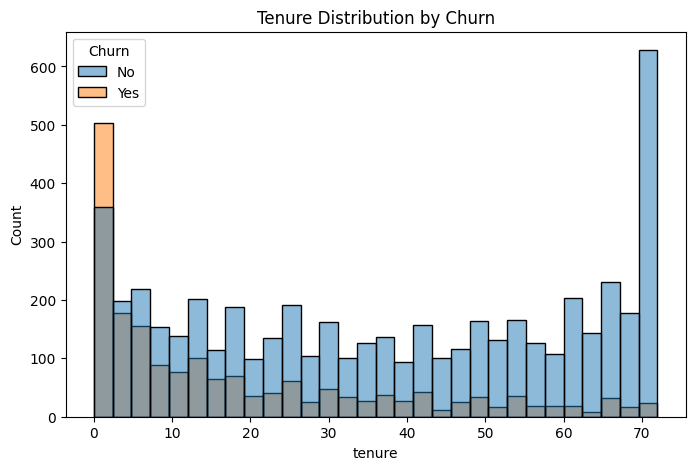

In [11]:
plt.figure(figsize = (8,5))
sns.histplot(data = df, x = "tenure", hue = "Churn", bins = 30)
plt.title("Tenure Distribution by Churn")
plt.show()

Customers with low tenure are most likely to churn. This data suggests early customer retention is importent.

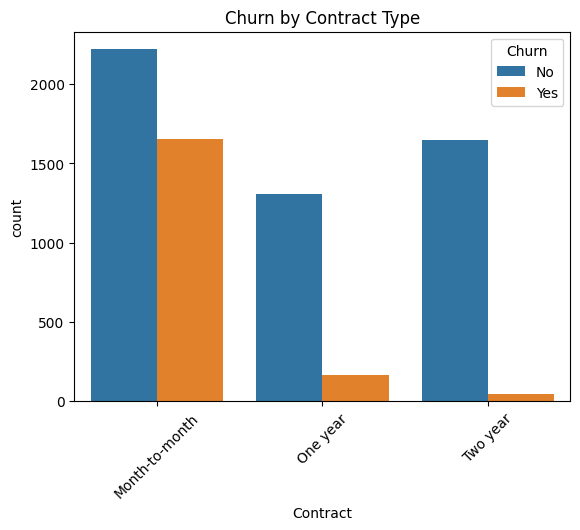

In [12]:
sns.countplot(x = "Contract", hue = "Churn", data = df)
plt.xticks(rotation = 45)
plt.title("Churn by Contract Type")
plt.show()

Month-to-month shows a higher churn rate compared to longer term contracts.

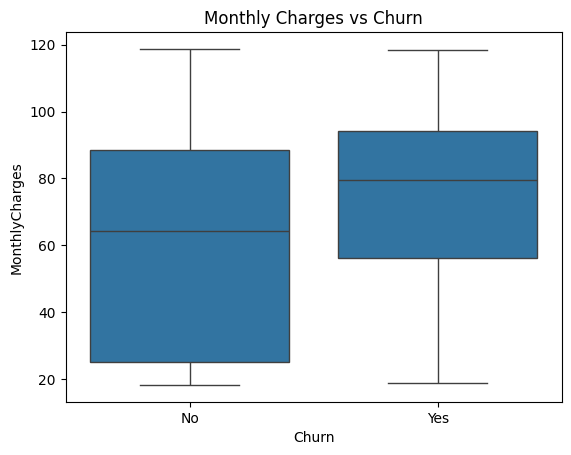

In [13]:
sns.boxplot(x = "Churn", y = "MonthlyCharges", data = df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers who churn tend to have higher monthly charges on average.

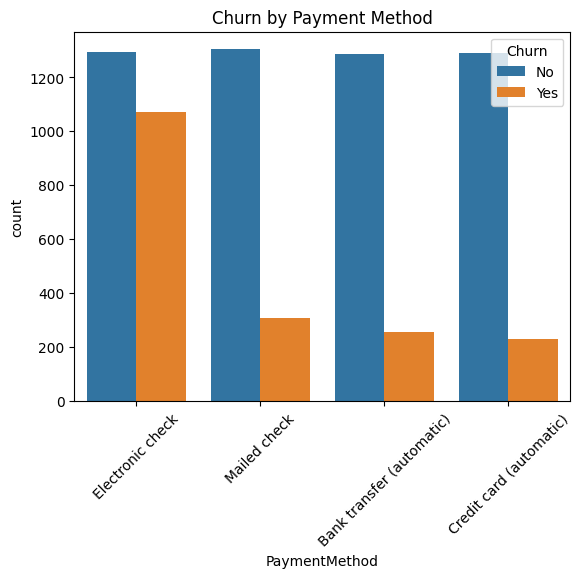

In [14]:
sns.countplot(x = "PaymentMethod", hue = "Churn", data = df)
plt.xticks(rotation = 45)
plt.title("Churn by Payment Method")
plt.show()

Electronic check may show the least retention amongst all payment methods.


## Cleaning

In [15]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [16]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

The TotalCharges data is impossible to plot when they are strings, so we convert them to floats.

In [17]:
# 1. On force la conversion en numérique (les espaces deviennent des NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. On remplace directement ces nouveaux NaN par 0 (clients avec ancienneté de 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. On vérifie que tout est propre
print("Valeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valeurs manquantes restantes :
Series([], dtype: int64)


In [18]:
df = df.drop("customerID", axis=1)

In [19]:
df = pd.get_dummies(df, drop_first=True)

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

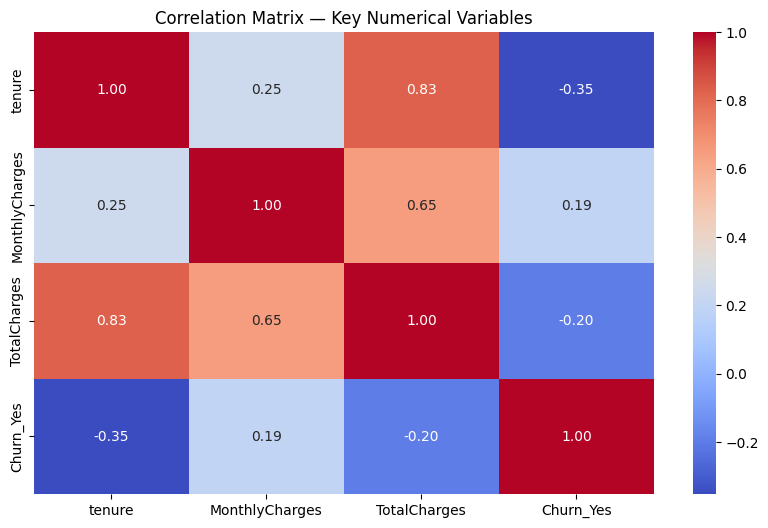

In [21]:
plt.figure(figsize=(10, 6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Yes']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix — Key Numerical Variables")
plt.show()

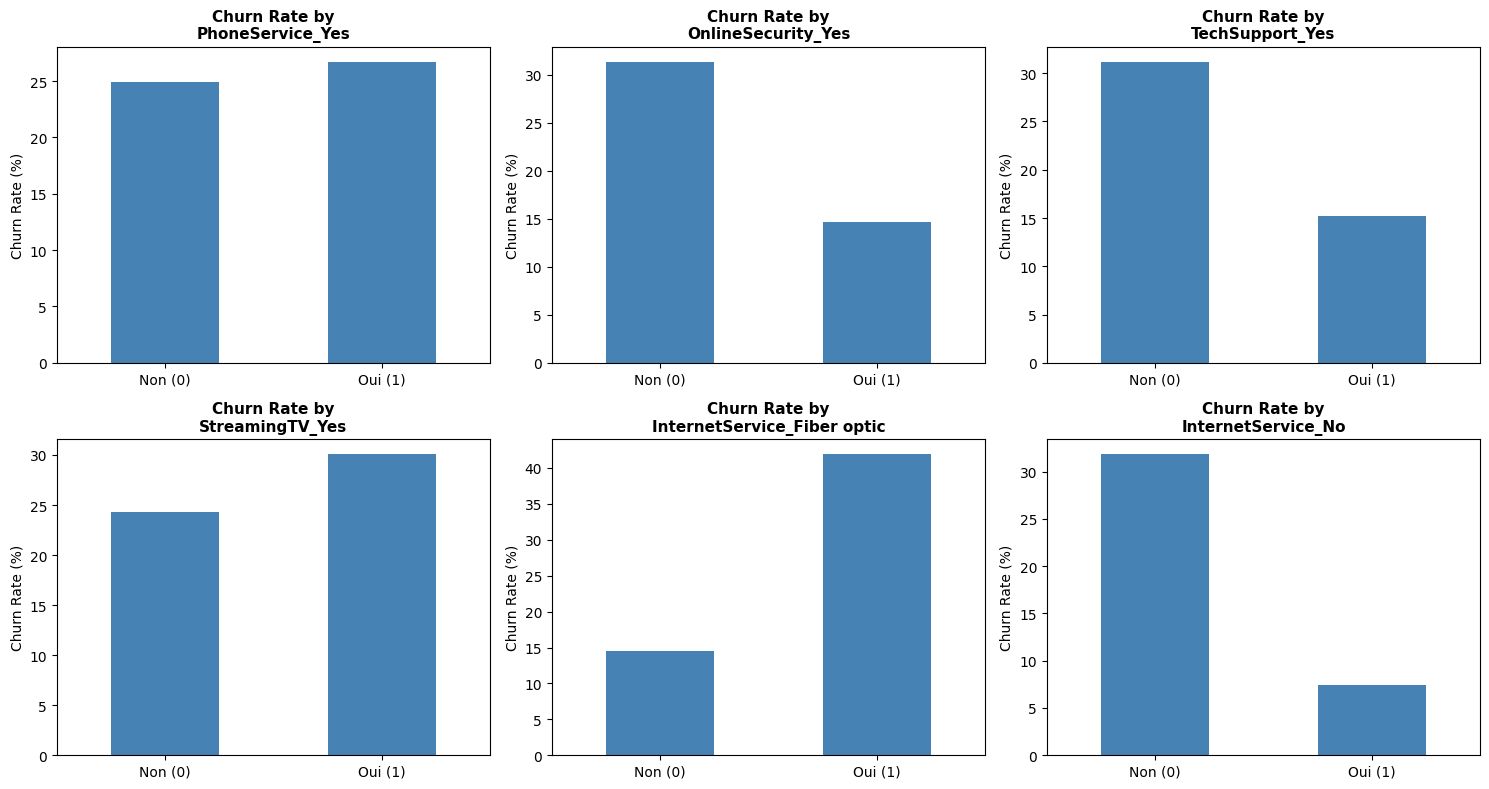

In [22]:
services_encodes = [
    'PhoneService_Yes', 
    'OnlineSecurity_Yes', 
    'TechSupport_Yes', 
    'StreamingTV_Yes',
    'InternetService_Fiber optic', 
    'InternetService_No'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(services_encodes):
    churn_rate = df.groupby(col)['Churn_Yes'].mean() * 100
    
    churn_rate.plot(kind='bar', ax=axes[i], color='steelblue')
    
    axes[i].set_title(f'Churn Rate by\n{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('') 
    axes[i].set_xticklabels(['Non (0)', 'Oui (1)'], rotation=0)

plt.tight_layout()
plt.show()